# Conditional 3D prediction

Generate one categorical volume with L-MPDD, Joint guidance, and optional one-pass categorical Refine. Inspect the final volume and optimization history directly.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.api import AnchorSlice, PredictOptions
from src.app.runtime import (
    build_dataset,
    build_loader,
    load_defaults,
    load_predict_config,
    load_predictor,
)
from src.modeling.phases import quantize_phase


def take_slice(volume, axis, index):
    return np.take(volume, index, axis=axis)


## Parameters

The two center anchors are compatible at their intersection. Replace either image independently when using real multi-axis conditions.

In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"

## Predict

The base-size path is L-MPDD latent sampling, Joint latent residual optimization, then optional one-pass categorical Refine. The final optimization result is returned without candidate selection or calibration.

In [3]:
model_runs, predict_config = load_predict_config(PREDICT_CONFIG)
model_runs = {
    name: None
    if path is None
    else Path(path) if Path(path).is_absolute() else ROOT / path
    for name, path in model_runs.items()
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**load_defaults(model_runs["vae_run_dir"] / "vae.yaml"))
args.data_dir = ROOT / args.data_dir
args.batch_size = 16

batch, _ = next(
    build_loader(build_dataset(args), args, device=torch.device("cpu"))
)
target_images = [
    quantize_phase(image, args.num_phases).numpy()
    for image in batch[:, 0]
]
phase_counts = np.bincount(
    np.stack(target_images).reshape(-1),
    minlength=args.num_phases,
)
reference_phase_fractions = tuple((phase_counts / phase_counts.sum()).tolist())
anchor_image = target_images[0]
center_index = anchor_image.shape[0] // 2
anchors = [
    AnchorSlice(image=anchor_image, axis=0, index=center_index),
    AnchorSlice(image=anchor_image.copy(), axis=1, index=center_index),
]
if predict_config["phase_fractions"] is None:
    predict_config["phase_fractions"] = reference_phase_fractions
options = PredictOptions(
    num_phases=args.num_phases,
    **predict_config,
)

predictor = load_predictor(**model_runs, device=device)
anchor_tensor = torch.as_tensor(anchor_image, device=device).float()[None, None]
with torch.no_grad():
    anchor_mean, _ = predictor.vae.encode(anchor_tensor)
    vae_anchor = predictor.vae.decode_probs(anchor_mean).argmax(dim=1)[0]
vae_anchor_mismatch = float((vae_anchor != anchor_tensor[0, 0]).float().mean())

start_time = time.perf_counter()
volume, stats = predictor.predict(
    options,
    anchors=anchors,
    target_images=target_images,
)
elapsed_seconds = time.perf_counter() - start_time
volume_np = volume.cpu().numpy()

print("device:", device)
print(f"elapsed: {elapsed_seconds:.1f} seconds")
print("volume:", volume_np.shape, volume.dtype)
print("target images:", len(target_images))
print("reference phase fraction:", np.round(reference_phase_fractions, 4).tolist())
print("anchors:", [(anchor.axis, anchor.index) for anchor in anchors])
joint_history = stats["joint_history"]
print("joint steps:", int(joint_history["step"].numel()))
print("refine applied:", bool(stats["refine_applied"]))
print("VAE anchor baseline:", round(vae_anchor_mismatch, 4))
print("anchor mismatches:", np.round(stats["final_anchor_mismatches"].cpu().numpy(), 4).tolist())
print("anchor phase mismatches:", np.round(stats["final_anchor_phase_mismatches"].cpu().numpy(), 4).tolist())
print("target phase fraction:", np.round(stats["final_target_phase_fraction"].cpu().numpy(), 4).tolist())
print("volume phase fraction:", np.round(stats["final_phase_fraction"].cpu().numpy(), 4).tolist())
print("critic enabled:", bool(stats["critic_enabled"]))
for name in ("loss", "axis", "axis_mass", "anchor"):
    if name in joint_history and joint_history[name].numel():
        print(f"final {name}: {float(joint_history[name][-1]):.4g}")

Joint guidance: 100%|██████████| 700/700 [03:15<00:00,  3.59it/s, loss=-0.6228, anchor=0.6245, critic=-33.32, fraction=0.04894, axis=0.1417] 


device: cuda
elapsed: 226.5 seconds
volume: (64, 64, 64) torch.uint8
target images: 16
reference phase fraction: [0.3167, 0.121, 0.5623]
anchors: [(0, 32), (1, 32)]
joint steps: 700
refine applied: True
VAE anchor baseline: 0.0989
anchor mismatches: [0.15139999985694885, 0.15360000729560852]
anchor phase mismatches: [[0.11999999731779099, 0.6345999836921692, 0.07959999889135361], [0.13609999418258667, 0.6514000296592712, 0.06880000233650208]]
target phase fraction: [0.3167000114917755, 0.12099999934434891, 0.5623000264167786]
volume phase fraction: [0.27070000767707825, 0.048700001090765, 0.6805999875068665]
critic enabled: True
final loss: -0.6228
final axis: 0.1417
final axis_mass: 1.205e-06
final anchor: 1.249


## Final diagnostics

Inspect the final result without applying heuristic pass/fail gates. Anchors are optimized softly and are never copied into the output.

axis transition rate: [0.12800000607967377, 0.1306000053882599, 0.12860000133514404]
axis run-profile MAE: [0.08349999785423279, 0.07259999960660934, 0.07909999787807465]
exact repeated-slice rate: [0.0, 0.0, 0.0]
near-duplicate slice rate: [0.0, 0.0, 0.0]
maximum repeat streak: [0, 0, 0]
global boundary jump: [0.04809999838471413, 0.07349999994039536, 0.04659999907016754]
anchor phase recall: [[0.8799999952316284, 0.3653999865055084, 0.9204000234603882], [0.8639000058174133, 0.34860000014305115, 0.9312000274658203]]
VAE anchor baseline: 0.0989
3D component count by phase: [61, 2604, 11]
3D Euler density by phase: [-0.0005489999894052744, 0.009612999856472015, -0.0010219999821856618]
phase/axis percolation: [[1, 1, 1], [0, 0, 0], [1, 1, 1]]


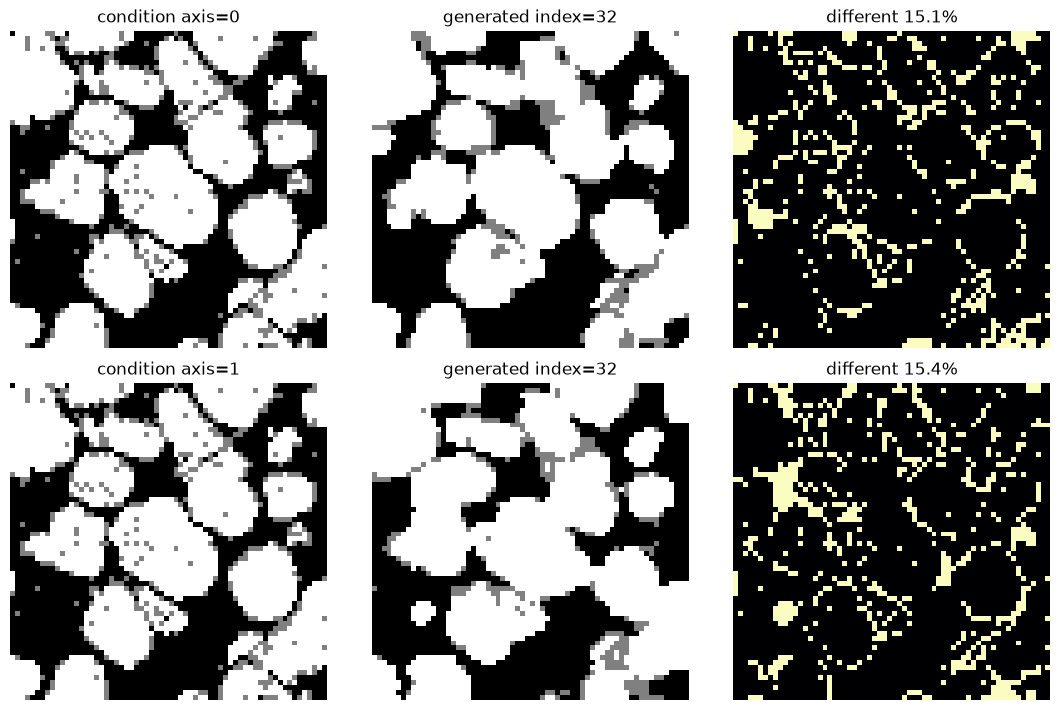

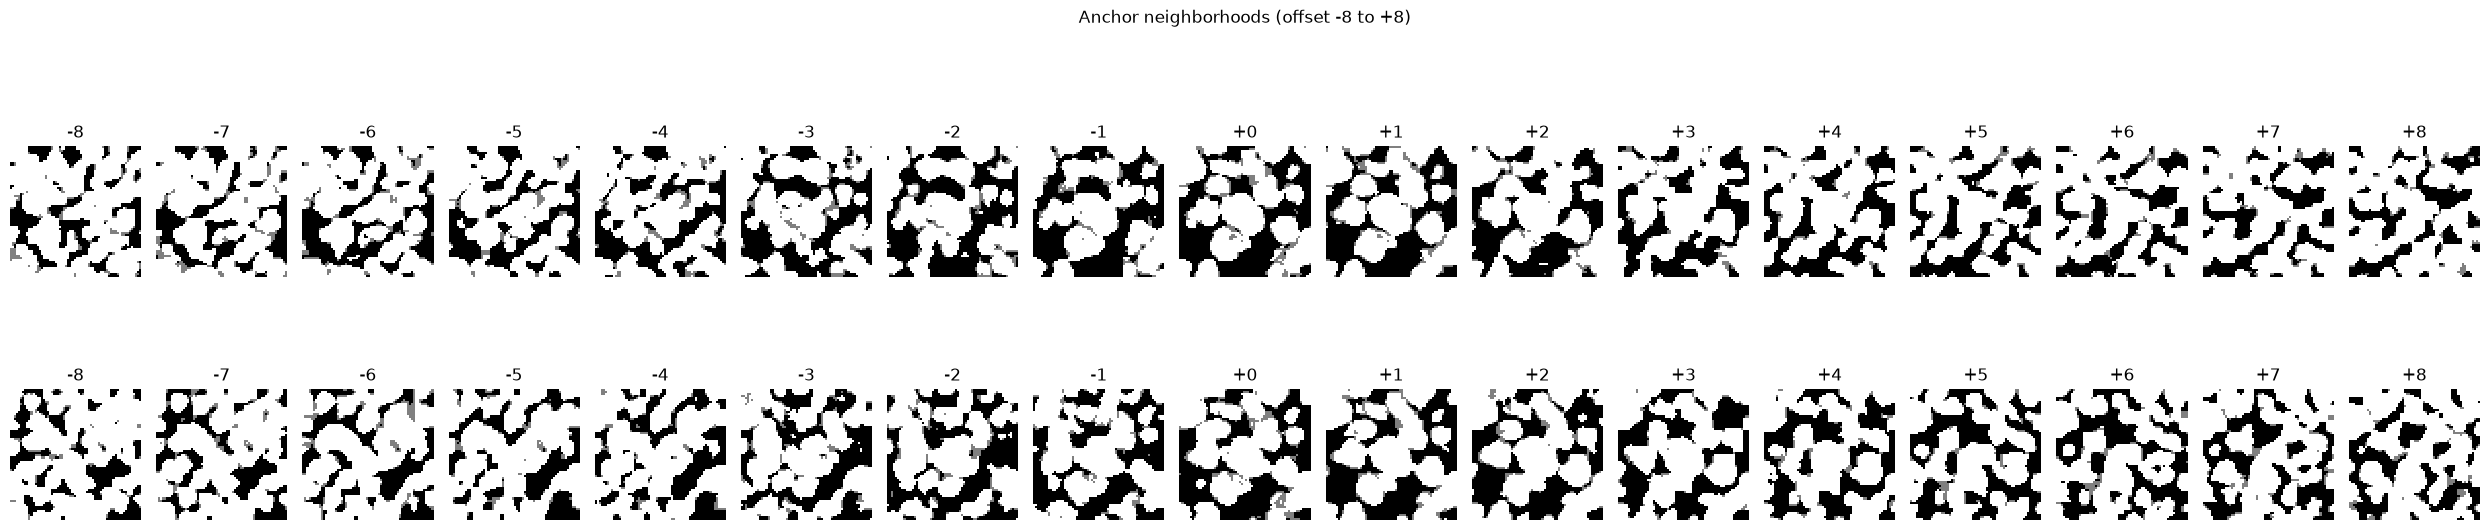

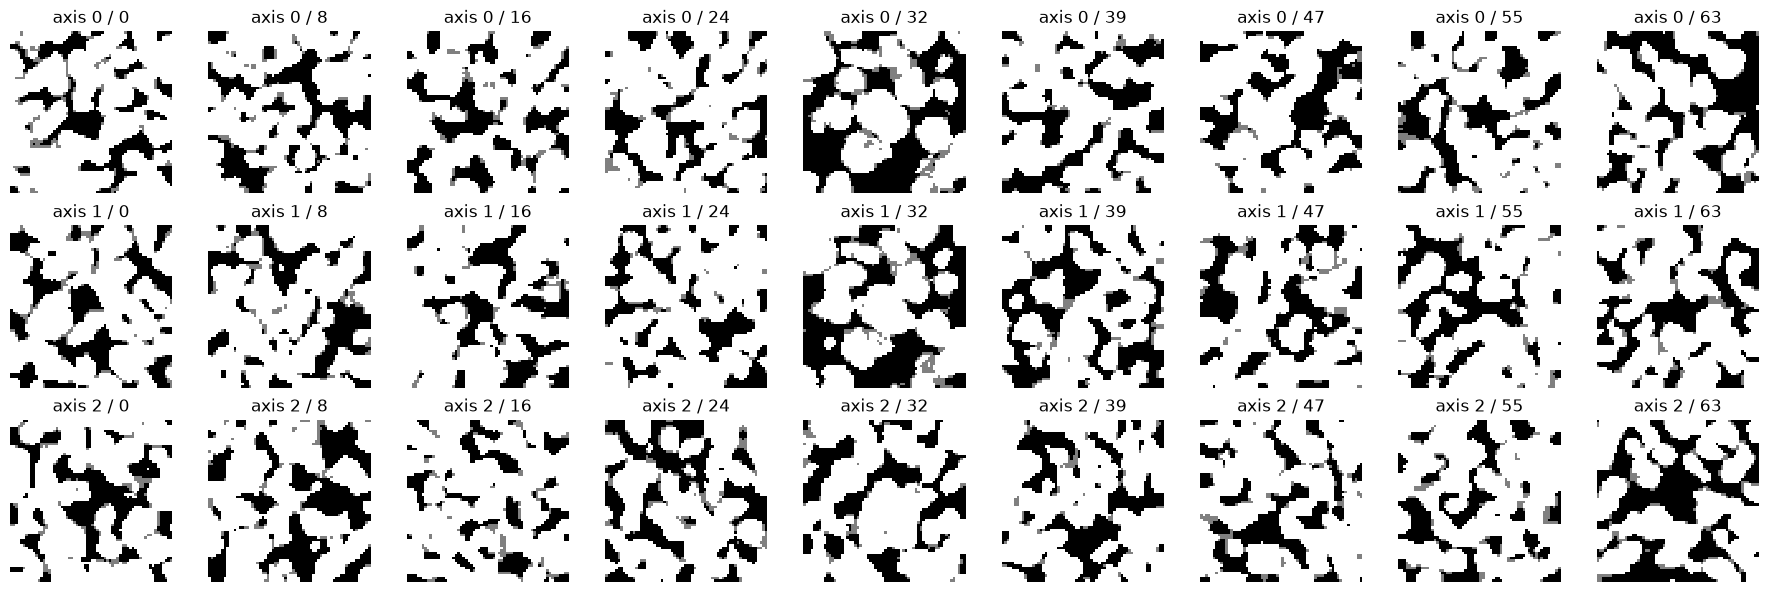

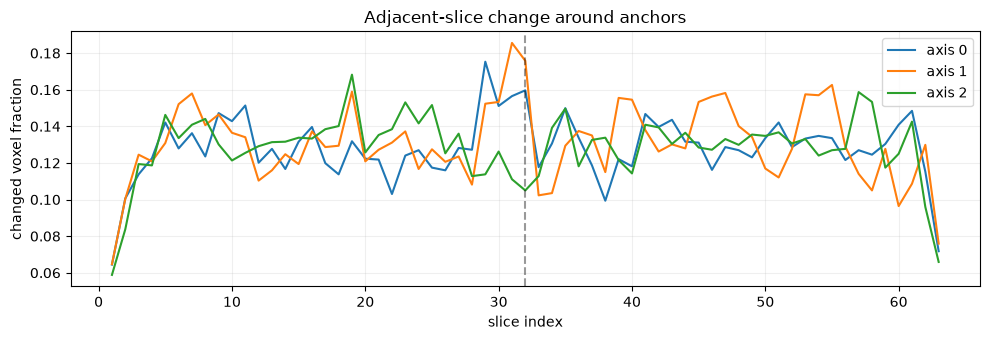

In [4]:
anchor_mismatches = stats["final_anchor_mismatches"].cpu().numpy()
anchor_phase_mismatches = stats["final_anchor_phase_mismatches"].cpu().numpy()
volume_phase_fraction = stats["final_phase_fraction"].cpu().numpy()
axis_transition_rate = stats["final_axis_transition_rate"].cpu().numpy()
axis_repeat_rate = stats["final_axis_exact_repeat_rate"].cpu().numpy()
axis_near_repeat_rate = stats["final_axis_near_repeat_rate"].cpu().numpy()
axis_repeat_streak = stats["final_axis_max_repeat_streak"].cpu().numpy()
axis_boundary_jump = stats["final_axis_global_boundary_jump"].cpu().numpy()
axis_run_mae = stats["final_axis_run_profile_mae"].cpu().numpy()
component_count = stats["final_component_count"].cpu().numpy()
euler_3d_density = stats["final_euler_3d_density"].cpu().numpy()
phase_axis_percolation = stats["final_phase_axis_percolation"].cpu().numpy()

print("axis transition rate:", np.round(axis_transition_rate, 4).tolist())
print("axis run-profile MAE:", np.round(axis_run_mae, 4).tolist())
print("exact repeated-slice rate:", np.round(axis_repeat_rate, 4).tolist())
print("near-duplicate slice rate:", np.round(axis_near_repeat_rate, 4).tolist())
print("maximum repeat streak:", axis_repeat_streak.astype(int).tolist())
print("global boundary jump:", np.round(axis_boundary_jump, 4).tolist())
print("anchor phase recall:", np.round(1.0 - anchor_phase_mismatches, 4).tolist())
print("VAE anchor baseline:", round(vae_anchor_mismatch, 4))
print("3D component count by phase:", component_count.astype(int).tolist())
print("3D Euler density by phase:", np.round(euler_3d_density, 6).tolist())
print("phase/axis percolation:", phase_axis_percolation.astype(int).tolist())

fig, axes = plt.subplots(len(anchors), 3, figsize=(11, 3.6 * len(anchors)), squeeze=False)
for row, anchor in enumerate(anchors):
    generated = take_slice(volume_np, anchor.axis, anchor.index)
    difference = generated != anchor.image
    panels = [
        (anchor.image, f"condition axis={anchor.axis}", "gray", 0, args.num_phases - 1),
        (generated, f"generated index={anchor.index}", "gray", 0, args.num_phases - 1),
        (difference, f"different {anchor_mismatches[row]:.1%}", "magma", 0, 1),
    ]
    for axis, (image, title, cmap, vmin, vmax) in zip(axes[row], panels):
        axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        axis.set_title(title)
        axis.axis("off")
plt.tight_layout()

offsets = np.arange(-8, 9)
fig, axes = plt.subplots(
    len(anchors),
    len(offsets),
    figsize=(25, 3.2 * len(anchors)),
    squeeze=False,
)
for row, anchor in enumerate(anchors):
    for column, offset in enumerate(offsets):
        index = anchor.index + int(offset)
        axes[row, column].imshow(
            take_slice(volume_np, anchor.axis, index),
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        axes[row, column].set_title(f"{offset:+d}")
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(f"axis {anchor.axis}")
fig.suptitle("Anchor neighborhoods (offset -8 to +8)")
plt.tight_layout()

indices = np.linspace(0, volume_np.shape[0] - 1, 9).round().astype(int)
fig, axes = plt.subplots(3, len(indices), figsize=(18, 6), squeeze=False)
for row, axis_id in enumerate(range(3)):
    for column, index in enumerate(indices):
        axes[row, column].imshow(
            take_slice(volume_np, axis_id, index),
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        axes[row, column].set_title(f"axis {axis_id} / {index}")
        axes[row, column].axis("off")
plt.tight_layout()

fig, profile_axis = plt.subplots(figsize=(10, 3.5))
for axis_id in range(3):
    adjacent_change = [
        np.mean(
            take_slice(volume_np, axis_id, index)
            != take_slice(volume_np, axis_id, index - 1)
        )
        for index in range(1, volume_np.shape[axis_id])
    ]
    profile_axis.plot(range(1, volume_np.shape[axis_id]), adjacent_change, label=f"axis {axis_id}")
for anchor_index in sorted({anchor.index for anchor in anchors}):
    profile_axis.axvline(anchor_index, color="black", linestyle="--", alpha=0.4)
profile_axis.set(
    title="Adjacent-slice change around anchors",
    xlabel="slice index",
    ylabel="changed voxel fraction",
)
profile_axis.legend()
profile_axis.grid(alpha=0.2)
plt.tight_layout()

## Interactive 3D view

Open the categorical prediction as an interactive 3D labels layer in napari. The Qt event loop keeps the viewer responsive from Jupyter.

In [ ]:
%gui qt
import napari

try:
    viewer.close()
except NameError:
    pass

viewer = napari.Viewer(ndisplay=3)
viewer.add_labels(
    volume_np.astype(np.int32, copy=False),
    name="prediction",
    opacity=0.8,
)
viewer.reset_view()
viewer
